1. データ概要
本データはパチンコ店舗の日次・機種単位データである。
目的変数は net_profit_yen（利益）とする。
主な特徴量：
・spins（総回転数）
・customers（利用客数）
・operating_hours（稼働時間）
・sales_yen（売上）
・event_flag（イベント日フラグ）

In [1]:
# ==========================================
# 0. Setup
# ==========================================

import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import train_model

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

df = pd.read_csv("../data/raw/pachinko_sales.csv")


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/pachinko_sales.csv'

2. 基本統計量と欠損確認

In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              248 non-null    str    
 1   weekday           248 non-null    str    
 2   machine_type      248 non-null    str    
 3   operating_hours   248 non-null    float64
 4   spins             248 non-null    int64  
 5   bonus_count       248 non-null    int64  
 6   gross_profit_yen  248 non-null    int64  
 7   sales_yen         248 non-null    int64  
 8   net_profit_yen    248 non-null    int64  
 9   customers         248 non-null    int64  
 10  event_flag        248 non-null    int64  
 11  weather           248 non-null    str    
dtypes: float64(1), int64(7), str(4)
memory usage: 23.4 KB


date                0
weekday             0
machine_type        0
operating_hours     0
spins               0
bonus_count         0
gross_profit_yen    0
sales_yen           0
net_profit_yen      0
customers           0
event_flag          0
weather             0
dtype: int64

考察
欠損値は確認されなかった。
数値カラムはすべて分析可能な状態である

3. 利益の分布

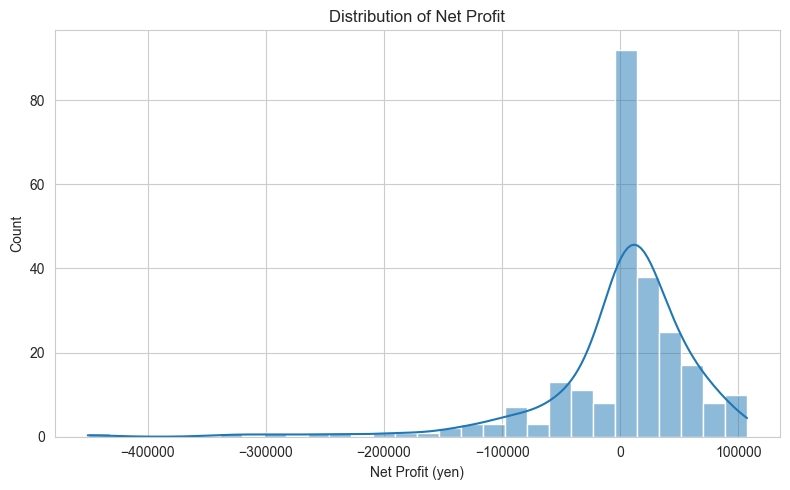

In [ ]:
plt.figure()
sns.histplot(df["net_profit_yen"], bins=30, kde=True)

plt.title("Distribution of Net Profit")
plt.xlabel("Net Profit (yen)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


考察

利益は0付近に集中しつつ、一部に高利益日が存在する右裾の長い分布を示した。

平均値のみでは実態を十分に把握できない可能性があるため、
RMSEとMAEの両方を評価指標として採用する。

4. 売上と利益の関係

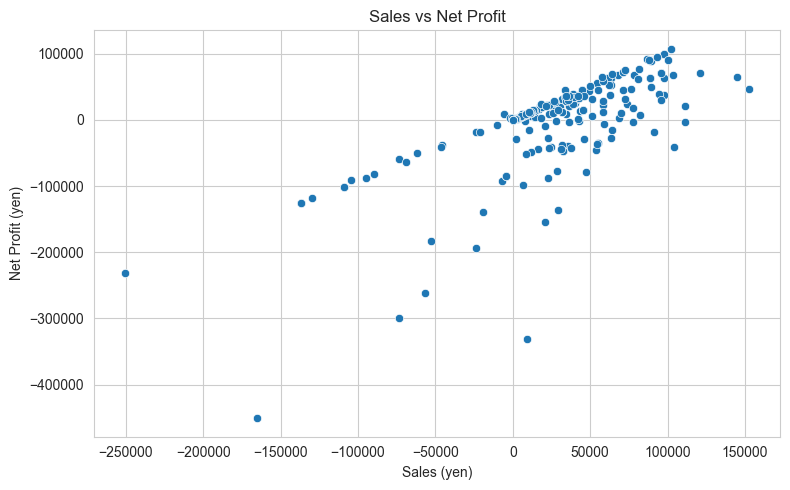

In [ ]:
plt.figure()
sns.scatterplot(
    x="sales_yen",
    y="net_profit_yen",
    data=df
)

plt.title("Sales vs Net Profit")
plt.xlabel("Sales (yen)")
plt.ylabel("Net Profit (yen)")
plt.tight_layout()
plt.show()


考察

売上と利益には明確な正の関係が確認された。

これは後のモデルにおいて
sales_yen が最も高い重要度を示した結果と整合的である。

利益は売上依存構造を持つ可能性が高い。

5. イベント有無による利益差

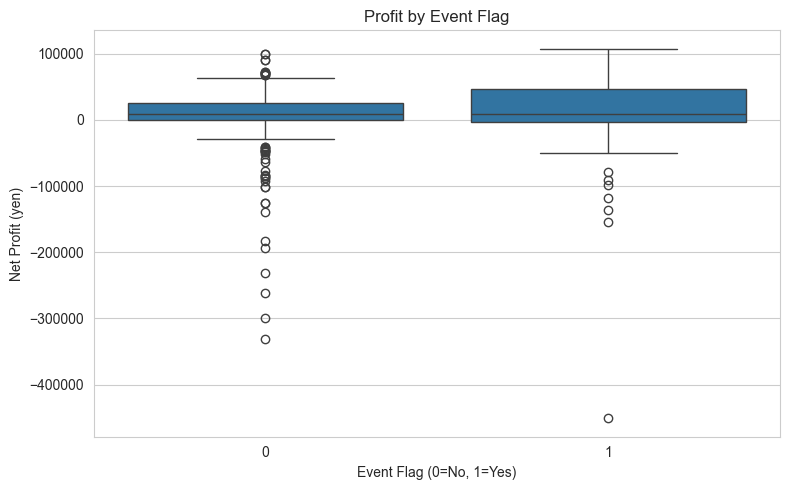

In [ ]:
plt.figure()
sns.boxplot(
    x="event_flag",
    y="net_profit_yen",
    data=df
)

plt.title("Profit by Event Flag")
plt.xlabel("Event Flag (0=No, 1=Yes)")
plt.ylabel("Net Profit (yen)")
plt.tight_layout()
plt.show()


考察

イベント日は利益が高くなる傾向が見られるが、
ばらつきも大きい。

イベント施策は利益向上の可能性を持つが、
安定的な効果を保証するものではないと考えられる。

6. 相関分析

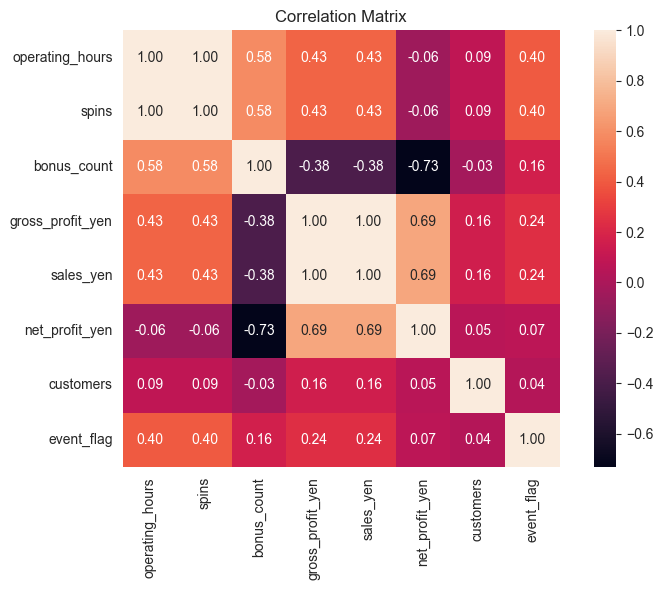

In [ ]:
plt.figure(figsize=(8, 6))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


考察
・sales_yen が net_profit_yen と最も強い相関を示した。
・spins や customers は中程度の相関。
・event_flag の単独影響は限定的。

この結果を踏まえ、
機械学習モデルによる利益予測を実施する。

7. 予測値と実測値の比較

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

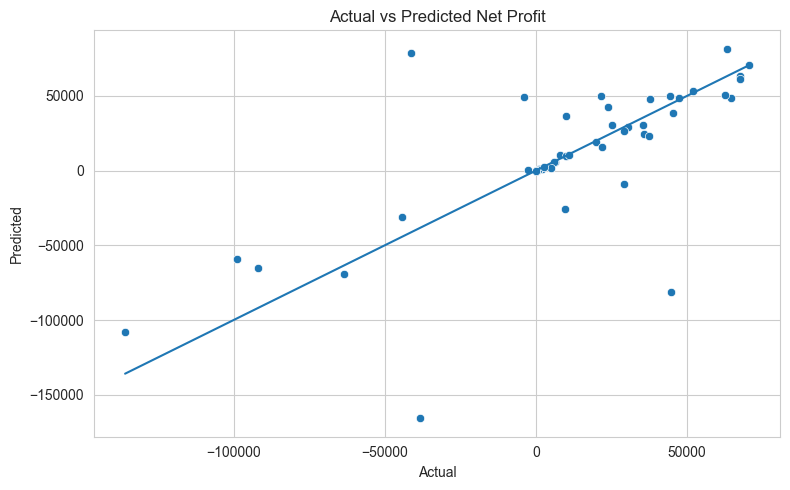

In [ ]:
# 予測
y_pred = model.predict(X_test)

plt.figure()

sns.scatterplot(x=y_test, y=y_pred)

# 45度線（理想ライン）
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted Net Profit")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()


考察
実測値と予測値の散布図より、
モデルは全体的な利益傾向は捉えているものの、
一部の高損失日や高利益日において予測誤差が大きいことが確認された。

特に極端値への対応が不十分であり、
特徴量設計やモデル改善の余地があると考えられる。

8. 残差の分布

In [ ]:
from src.model import train_model

feature_cols = [
    "spins",
    "customers",
    "event_flag",
    "operating_hours",
    "sales_yen"
]

target_col = "net_profit_yen"

model, X_test, y_test = train_model(df, feature_cols, target_col)


In [ ]:
y_pred = model.predict(X_test)

residuals = y_test - y_pred


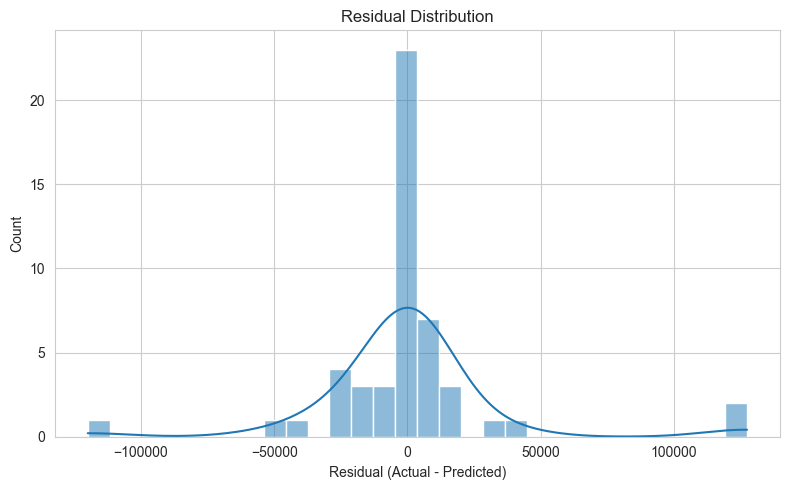

In [ ]:
residuals = y_test - y_pred

plt.figure()
sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


考察

残差はおおよそ0付近に集中しているが、
一部に大きな誤差が存在する。

モデルは全体傾向は捉えているものの、
高利益日などの極端値への対応が課題と考えられる。